In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Setup Successful")

Setup Successful


In [2]:
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")
nav_df = pd.read_csv("../data/processed/clean_nav_history.csv")
trans_df = pd.read_csv("../data/processed/clean_investor_transactions.csv")
perf_df = pd.read_csv("../data/processed/clean_scheme_performance.csv")

print("All datasets loaded")

All datasets loaded


In [3]:
nav_df.head()

,amfi_code,date,nav
0,119551,03-01-2022,54.3856
1,119551,04-01-2022,54.3474
2,119551,05-01-2022,54.6869
3,119551,06-01-2022,55.4550
4,119551,07-01-2022,55.3692


In [4]:
nav_df.shape

(46000, 3)

In [6]:
nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    dayfirst=True
)

nav_df.dtypes

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object

In [7]:
daily_nav = (
    nav_df.groupby("date")["nav"]
    .mean()
    .reset_index()
)

daily_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


In [8]:
daily_nav = (
    nav_df.groupby("date")["nav"]
    .mean()
    .reset_index()
)

daily_nav.head()

,date,nav
0,2022-01-03,207.213793
1,2022-01-04,206.890585
2,2022-01-05,207.226548
3,2022-01-06,207.190405
4,2022-01-07,207.081100


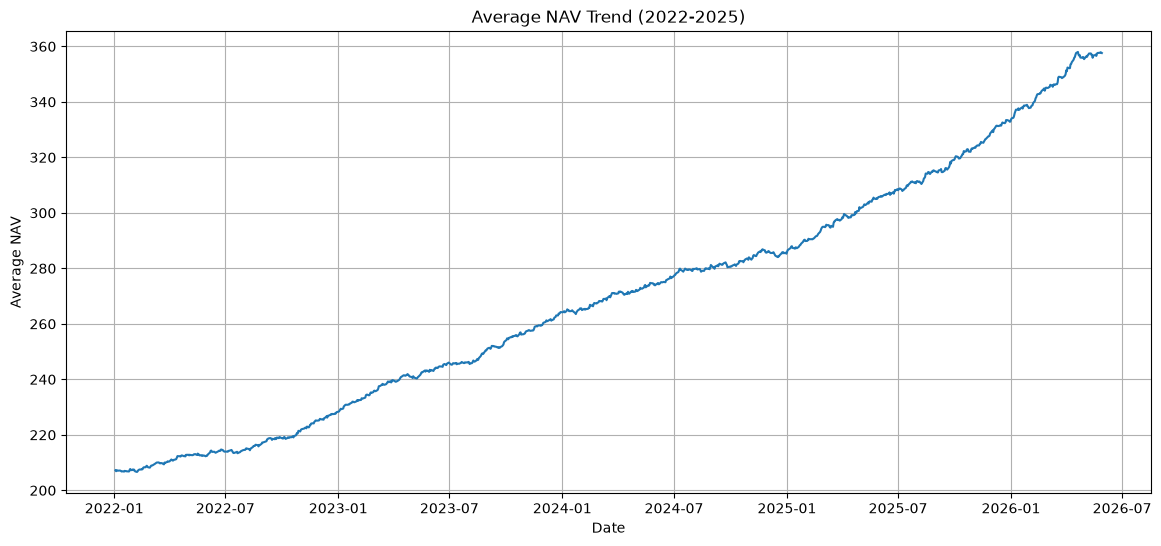

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    daily_nav["date"],
    daily_nav["nav"]
)

plt.title("Average NAV Trend (2022-2025)")
plt.xlabel("Date")
plt.ylabel("Average NAV")
plt.grid(True)

plt.show()

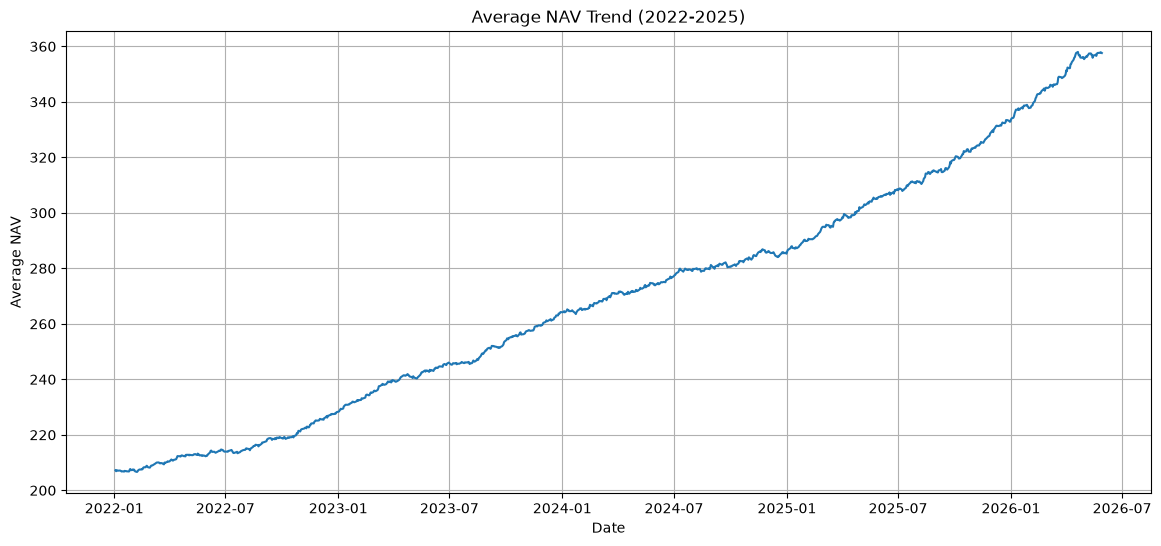

In [10]:
plt.figure(figsize=(14,6))

plt.plot(daily_nav["date"], daily_nav["nav"])

plt.title("Average NAV Trend (2022-2025)")
plt.xlabel("Date")
plt.ylabel("Average NAV")

plt.grid(True)

plt.savefig("../reports/nav_trend.png")

plt.show()

In [11]:
perf_df.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [12]:
perf_df[["fund_house","aum_crore"]].head()

,fund_house,aum_crore
0,SBI Mutual Fund,14288
1,SBI Mutual Fund,1231
2,SBI Mutual Fund,19259
3,SBI Mutual Fund,36061
4,SBI Mutual Fund,24101


In [13]:
aum_by_amc = (
    perf_df.groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

aum_by_amc

,fund_house,aum_crore
0,Nippon India MF,154328
1,Kotak Mahindra MF,145689
2,ICICI Prudential MF,120241
3,DSP Mutual Fund,114787
4,Aditya Birla Sun Life MF,104108
5,SBI Mutual Fund,94940
6,Axis Mutual Fund,92210
7,HDFC Mutual Fund,86975
8,UTI Mutual Fund,66990
9,Mirae Asset MF,63396


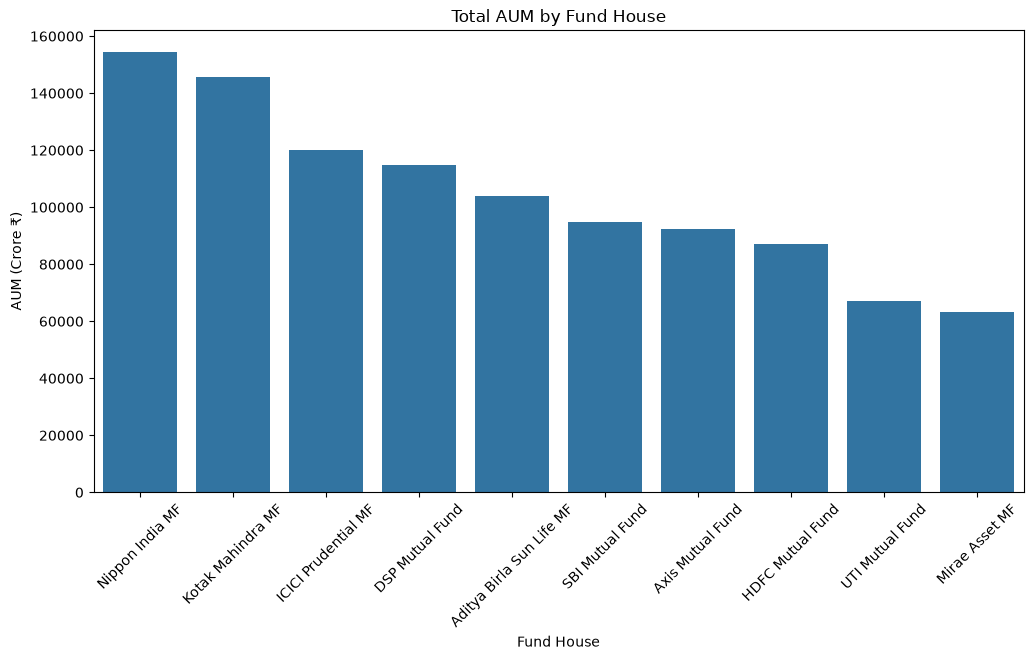

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_by_amc,
    x="fund_house",
    y="aum_crore"
)

plt.title("Total AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore ₹)")

plt.xticks(rotation=45)

plt.show()

### Key Findings

- Nippon India MF has the highest total Assets Under Management (AUM) among all fund houses.
- Kotak Mahindra MF and ICICI Prudential MF are also among the top contributors.
- SBI Mutual Fund maintains a strong market presence with a significant AUM base.
- The top fund houses account for a major share of the total mutual fund assets.
- UTI Mutual Fund and Mirae Asset MF have comparatively lower AUM in this dataset.

In [15]:
trans_df["transaction_type"].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [17]:
trans_df["transaction_date"].head(10)

0    01-01-2024
1    01-01-2024
2    01-01-2024
3    01-01-2024
4    01-01-2024
5    01-01-2024
6    01-01-2024
7    01-01-2024
8    01-01-2024
9    01-01-2024
Name: transaction_date, dtype: str

In [18]:
trans_df["transaction_date"].sample(5)

27879    15-03-2025
26827    26-02-2025
22683    23-12-2024
11989    06-07-2024
24308    17-01-2025
Name: transaction_date, dtype: str

In [19]:
trans_df["transaction_date"] = pd.to_datetime(
    trans_df["transaction_date"],
    format="mixed",
    dayfirst=True
)

In [20]:
print(trans_df["transaction_date"].head(20))

0    2024-01-01
1    2024-01-01
2    2024-01-01
3    2024-01-01
4    2024-01-01
5    2024-01-01
6    2024-01-01
7    2024-01-01
8    2024-01-01
9    2024-01-01
10   2024-01-01
11   2024-01-01
12   2024-01-01
13   2024-01-01
14   2024-01-01
15   2024-01-01
16   2024-01-01
17   2024-01-01
18   2024-01-01
19   2024-01-01
Name: transaction_date, dtype: datetime64[us]


In [21]:
sip_df = trans_df[
    trans_df["transaction_type"] == "SIP"
]

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [22]:
monthly_sip = (
    sip_df
    .groupby(
        sip_df["transaction_date"].dt.to_period("M")
    )["amount_inr"]
    .sum()
    .reset_index()
)

monthly_sip["transaction_date"] = monthly_sip["transaction_date"].astype(str)

monthly_sip.head()

,transaction_date,amount_inr
0,2024-01,12635349
1,2024-02,12613376
2,2024-03,12088413
3,2024-04,13512385
4,2024-05,13218606


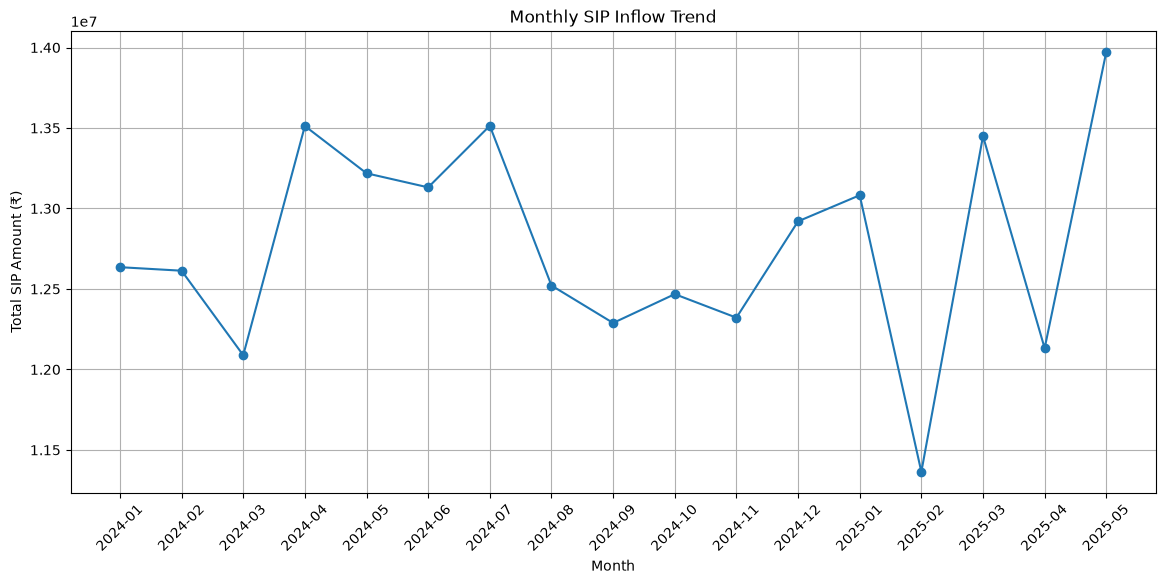

In [23]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sip["transaction_date"],
    monthly_sip["amount_inr"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("Total SIP Amount (₹)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

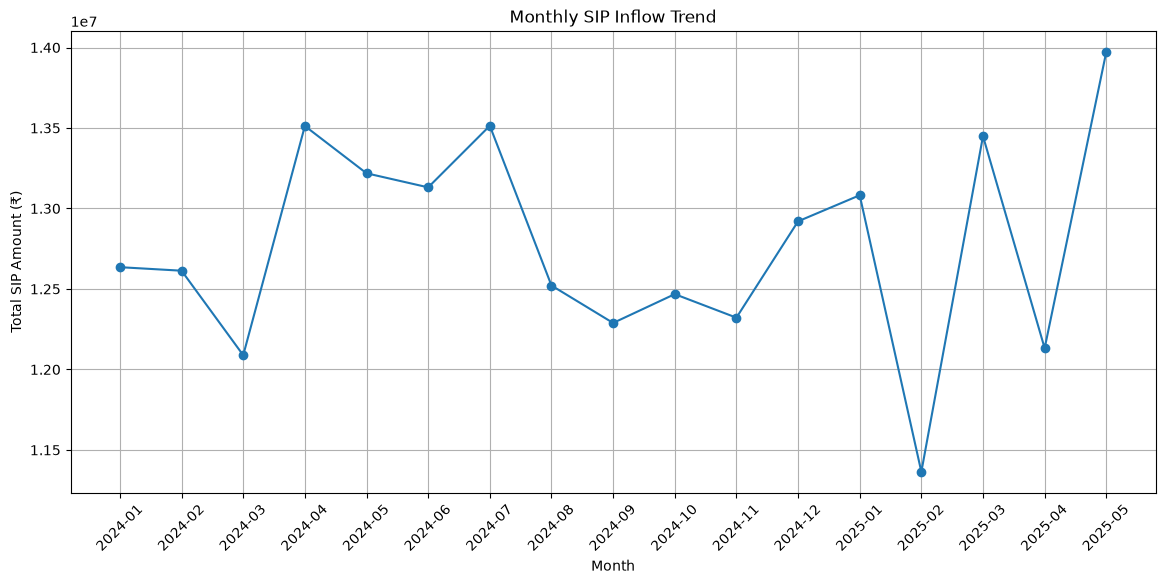

In [24]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sip["transaction_date"],
    monthly_sip["amount_inr"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("Total SIP Amount (₹)")

plt.xticks(rotation=45)

plt.grid(True)

plt.savefig("../reports/sip_inflow_trend.png")

plt.show()

### Key Findings

- SIP inflows remained relatively stable throughout the analysis period, indicating consistent investor participation.
- Strong growth was observed during April 2024, July 2024, and March 2025.
- February 2025 recorded the lowest SIP inflow, suggesting a temporary decline in investment activity.
- The highest SIP inflow was observed in May 2025, indicating increased investor confidence and participation.
- Overall, SIP investments show a positive long-term trend with periodic fluctuations.

In [25]:
fund_df.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [26]:
fund_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [27]:
merged_df = trans_df.merge(
    fund_df[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)

merged_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,category
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,Equity
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,Equity
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,Debt
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,Equity
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,Equity


In [28]:
merged_df["month"] = merged_df["transaction_date"].dt.to_period("M")

merged_df[["month", "category"]].head()

,month,category
0,2024-01,Equity
1,2024-01,Equity
2,2024-01,Debt
3,2024-01,Equity
4,2024-01,Equity


In [29]:
heatmap_data = (
    merged_df.groupby(["month", "category"])["amount_inr"]
    .sum()
    .reset_index()
)

heatmap_data.head()

,month,category,amount_inr
0,2024-01,Debt,38451525
1,2024-01,Equity,179196780
2,2024-02,Debt,26900057
3,2024-02,Equity,166989359
4,2024-03,Debt,29666220


In [30]:
heatmap_pivot = heatmap_data.pivot(
    index="month",
    columns="category",
    values="amount_inr"
)

heatmap_pivot.head()

category,Debt,Equity
month,,
2024-01,38451525,179196780
2024-02,26900057,166989359
2024-03,29666220,183787278
2024-04,29859025,178644849
2024-05,30626799,174499553


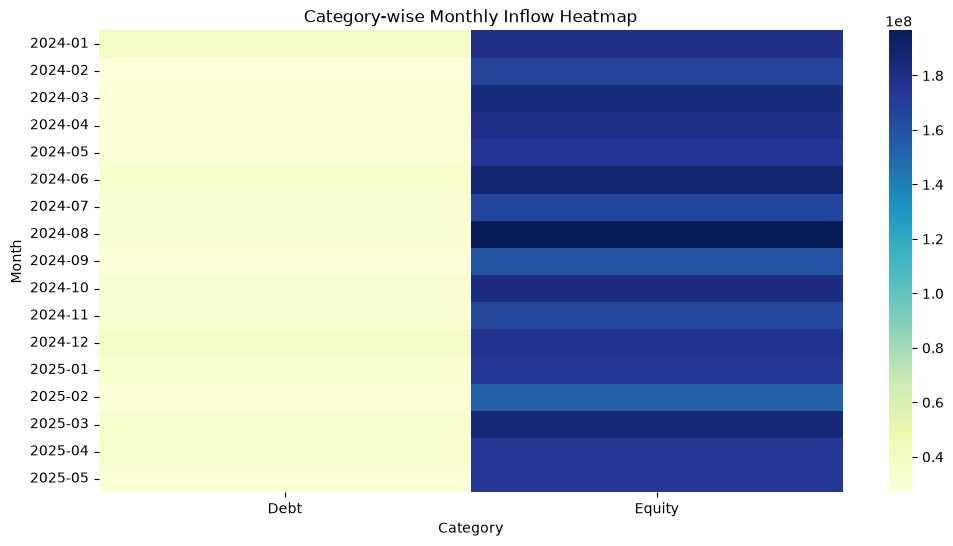

In [31]:
plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_pivot,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Monthly Inflow Heatmap")
plt.xlabel("Category")
plt.ylabel("Month")

plt.show()

### Key Findings

- Equity funds consistently attracted significantly higher inflows compared to Debt funds throughout the analysis period.
- August 2024 recorded one of the highest inflow periods for Equity schemes.
- February 2025 showed a noticeable decline in Equity inflows, matching the SIP trend analysis.
- Debt fund inflows remained relatively stable with lower volatility.
- Overall investor preference remained strongly tilted towards Equity funds, indicating higher risk appetite and long-term wealth creation focus.

In [32]:
trans_df["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

In [33]:
trans_df[["age_group","amount_inr"]].head()

,age_group,amount_inr
0,56+,1834
1,18-25,392882
2,36-45,912
3,36-45,1102
4,26-35,8682


In [34]:
age_counts = trans_df["age_group"].value_counts()

age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

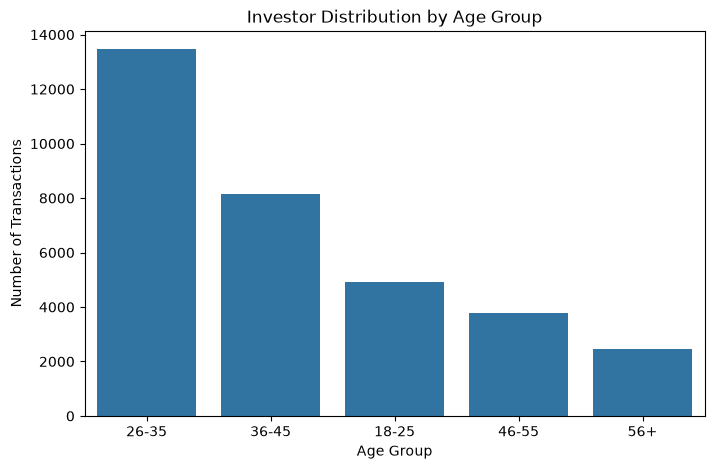

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=trans_df,
    x="age_group",
    order=trans_df["age_group"].value_counts().index
)

plt.title("Investor Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

plt.show()

In [36]:
sip_age = trans_df[
    trans_df["transaction_type"] == "SIP"
]

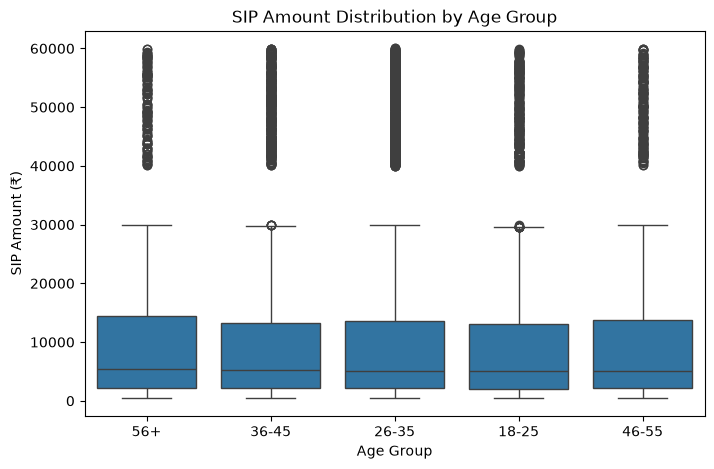

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=sip_age,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.show()

### Key Findings

- The majority of transactions were generated by investors in the 26–35 and 36–45 age groups.
- Younger investors (18–25) participated actively but with relatively smaller investment amounts.
- Mid-career investors showed higher SIP contributions and greater investment activity.
- Senior investors (56+) participated less frequently but still contributed meaningful investment amounts.
- Investment behavior varies across age groups, reflecting differences in income levels and financial goals.

In [38]:
trans_df["state"].value_counts().head(10)

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Name: count, dtype: int64

In [39]:
state_inflow = (
    trans_df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_inflow.head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

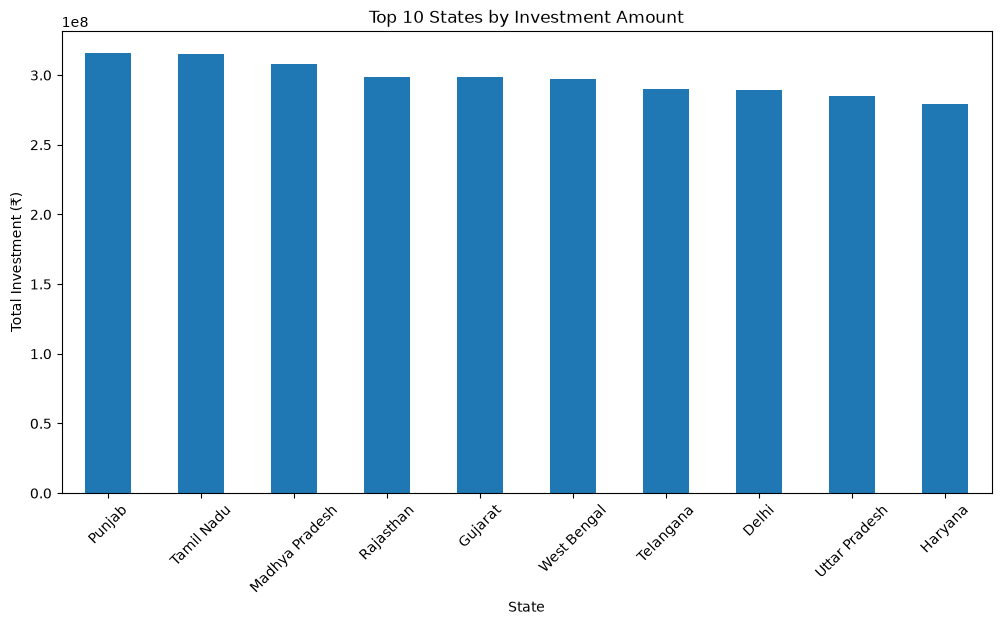

In [40]:
plt.figure(figsize=(12,6))

state_inflow.head(10).plot(kind="bar")

plt.title("Top 10 States by Investment Amount")
plt.xlabel("State")
plt.ylabel("Total Investment (₹)")

plt.xticks(rotation=45)
plt.show()

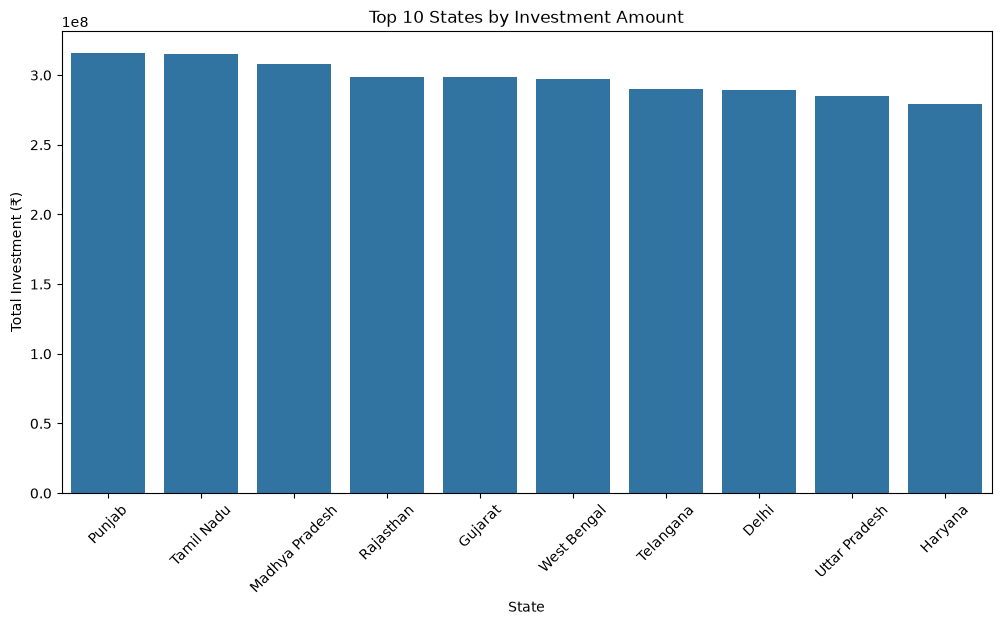

In [41]:
top_states = state_inflow.head(10).reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_states,
    x="state",
    y="amount_inr"
)

plt.title("Top 10 States by Investment Amount")
plt.xlabel("State")
plt.ylabel("Total Investment (₹)")

plt.xticks(rotation=45)
plt.show()

## Key Findings
Punjab recorded the highest total investment inflow among all states in the dataset.
Tamil Nadu and Madhya Pradesh were also among the top contributors.
Rajasthan, Gujarat, and West Bengal showed strong investment participation.
The difference between the top states was relatively small, indicating broad investor participation across regions.
Investment activity was well distributed rather than concentrated in a single state.
Geographic analysis revealed multiple high-potential markets for mutual fund growth.

In [42]:
trans_df["transaction_date"].head()

0   2024-01-01
1   2024-01-01
2   2024-01-01
3   2024-01-01
4   2024-01-01
Name: transaction_date, dtype: datetime64[us]

In [43]:
folio_growth = (
    trans_df.groupby(
        trans_df["transaction_date"].dt.to_period("M")
    )["investor_id"]
    .nunique()
    .reset_index()
)

folio_growth.columns = ["month", "folio_count"]

folio_growth.head()

,month,folio_count
0,2024-01,1577
1,2024-02,1530
2,2024-03,1592
3,2024-04,1558
4,2024-05,1551


In [44]:
folio_growth["month"] = (
    folio_growth["month"]
    .astype(str)
)

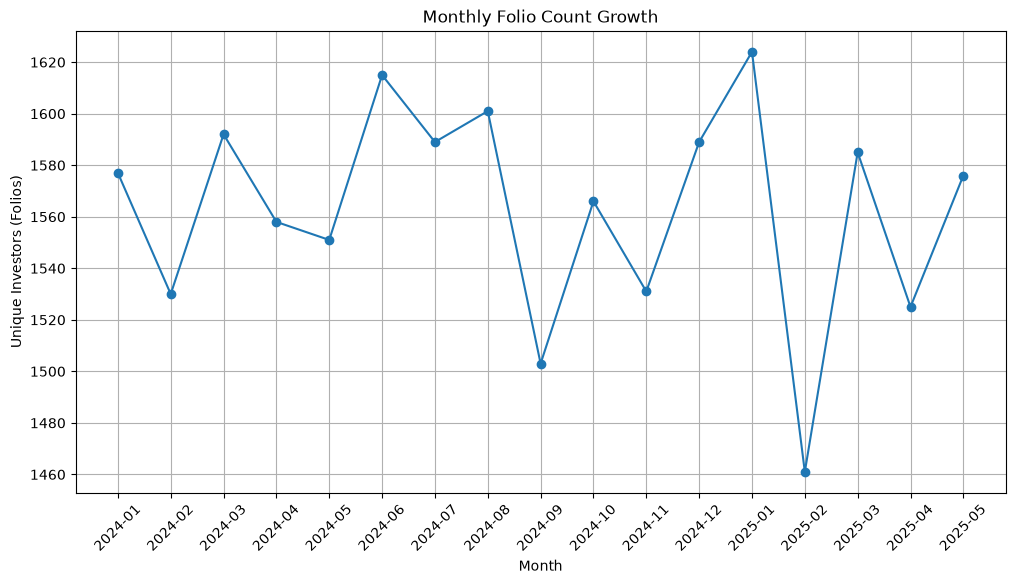

In [45]:
plt.figure(figsize=(12,6))

plt.plot(
    folio_growth["month"],
    folio_growth["folio_count"],
    marker="o"
)

plt.title("Monthly Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Unique Investors (Folios)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## Key Findings
Monthly folio counts remained relatively stable between 1,460 and 1,625 investors.
The highest folio count was recorded in January 2025.
A noticeable decline occurred in February 2025, followed by recovery in March 2025.
Investor participation showed periodic fluctuations rather than a consistent upward or downward trend.
Overall, the investor base remained stable throughout the observed period.

In [46]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [47]:
nav_df.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [48]:
selected_funds = (
    nav_df["amfi_code"]
    .unique()[:10]
)

selected_funds

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025])

In [49]:
nav_subset = nav_df[
    nav_df["amfi_code"].isin(selected_funds)
]

nav_subset.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [50]:
nav_pivot = nav_subset.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [51]:
returns = nav_pivot.pct_change()

returns.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.001001,-0.005010
2022-01-05,0.012865,-0.000050,-0.004386,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.004250,-0.005184
2022-01-06,-0.011377,-0.001880,-0.005167,0.003598,0.014045,-0.011091,0.004824,-0.007924,-0.003589,-0.002706
2022-01-07,-0.001210,0.002036,-0.005748,-0.002465,-0.001547,0.015111,0.032830,-0.044252,-0.002719,-0.012660


In [52]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454
119552,0.013663,-0.002803,-0.027471,-0.004003,-0.006819,1.000000,0.020754,-0.042415,0.027796,-0.052299
119598,-0.030296,-0.065019,0.006659,0.018423,0.024409,0.020754,1.000000,0.018187,-0.053278,0.018443
119599,-0.000007,-0.034061,-0.028323,0.017795,-0.072559,-0.042415,0.018187,1.000000,0.003347,0.041927
125497,0.047139,0.011326,-0.025137,-0.010542,0.016469,0.027796,-0.053278,0.003347,1.000000,0.027394


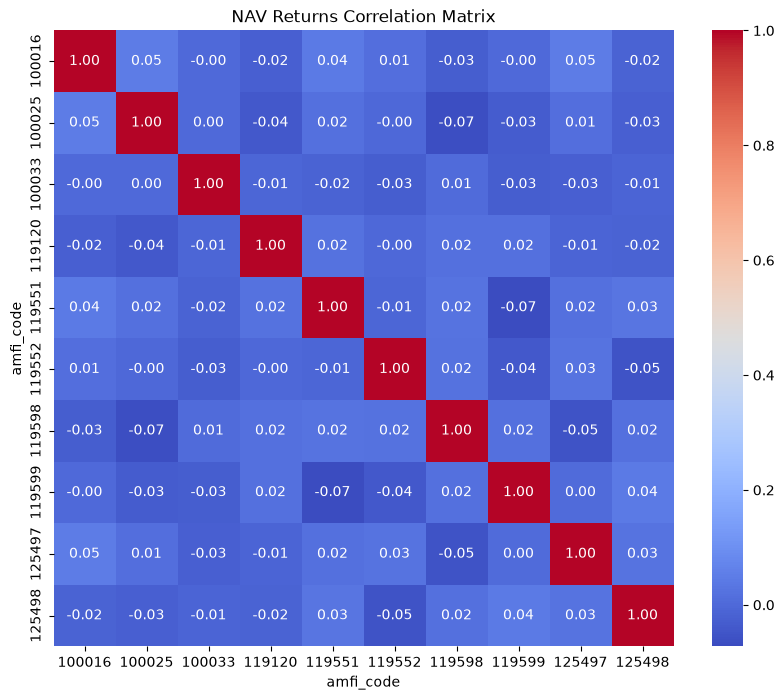

In [53]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Returns Correlation Matrix")

plt.show()

## key findings
Most correlation values were close to zero.
No strong positive correlations were observed among the selected funds.
Negative correlations were also very weak.
The selected funds largely moved independently during the analyzed period.
The results suggest potential diversification benefits when combining these funds in a portfolio.
No fund pair showed a correlation high enough to indicate near-identical performance behavior.

In [54]:
holdings_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [55]:
holdings_df.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [56]:
sector_allocation = (
    holdings_df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_allocation

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

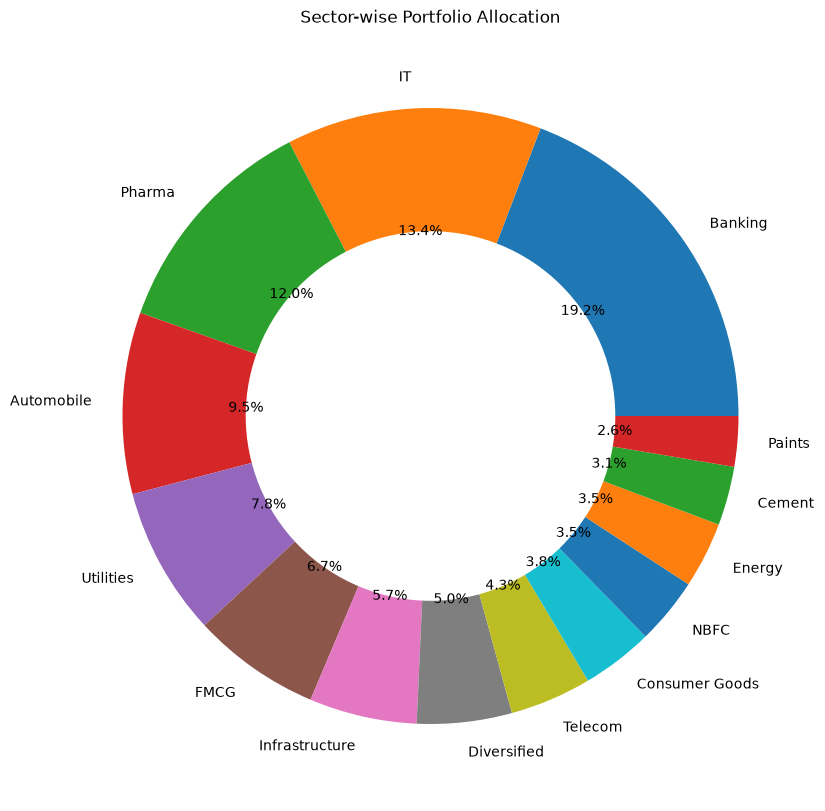

In [57]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_allocation,
    labels=sector_allocation.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector-wise Portfolio Allocation")

plt.show()

## Key Findings
Banking sector had the highest allocation at approximately 19%.
IT and Pharma were the next largest sectors with significant exposure.
Automobile and Utilities also contributed meaningful allocations.
Sector exposure was distributed across multiple industries, indicating diversification.
No single sector dominated the portfolio excessively, reducing concentration risk.

# EDA Findings Summary

## Project Objective

The objective of this analysis was to study mutual fund performance, investor behavior, fund inflows, portfolio allocation, and overall investment trends using NAV history, transaction data, performance metrics, and portfolio holdings datasets.

## Major Findings

### NAV Trend Analysis

* Average NAV showed a steady upward trend from 2022 to 2025.
* Growth accelerated during 2025, indicating positive market performance.
* Long-term fund performance remained healthy.

### AUM Analysis

* Nippon India MF and Kotak Mahindra MF had the highest AUM.
* AUM was concentrated among leading fund houses.
* Large AMCs dominated industry assets.

### SIP Inflow Analysis

* Monthly SIP inflows remained relatively stable.
* Peak inflows were observed during selected months in 2025.
* SIP investments continued to be a major investment route.

### Category-wise Analysis

* Equity funds attracted significantly higher investments compared to Debt funds.
* Investors showed a stronger preference for equity-oriented schemes.

### Investor Demographics

* Age group 26–35 represented the largest share of investors.
* Younger investors showed strong participation in mutual funds.
* SIP amount distributions were relatively similar across age groups.

### Geographic Analysis

* Punjab, Tamil Nadu, and Madhya Pradesh contributed the highest investment amounts.
* Investments were distributed across multiple states, indicating broad participation.

### Folio Growth Analysis

* Monthly folio count remained stable throughout the period.
* Investor participation fluctuated slightly but showed no major decline.
* The highest folio count was recorded in early 2025.

### Correlation Analysis

* Most selected funds exhibited weak correlations.
* Diversification opportunities existed across different funds.
* No strong dependency was observed among fund returns.

### Sector Allocation Analysis

* Banking sector had the highest portfolio allocation.
* IT and Pharma sectors also held significant weights.
* Portfolio exposure was diversified across multiple industries.

## Conclusion

The mutual fund ecosystem demonstrated healthy growth, stable investor participation, consistent SIP inflows, and diversified portfolio allocation. Equity funds remained the preferred investment choice, while sector allocation and correlation analysis indicated balanced diversification and manageable investment risk.
